# Render  Tempest 2000 Web Gradually

In [1]:
from IPython.display import display, HTML
# Increase the width
display(HTML("<style>.container { width:60% !important; }</style>"))


In [80]:
#Import libraries
import math
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

SCALE_FACTOR = 0.4
projected = lambda x,m: x + OFFSET if x < m else x - OFFSET

def scale(x,y,centre):
    x_mid,y_mid = centre
    x -= x_mid
    y -= y_mid
    x *= SCALE_FACTOR
    y *= SCALE_FACTOR
    x += x_mid
    y += y_mid
    return (x,y)

def getCentre(vertices):
    x_max = max([x for x,_ in vertices])
    x_min = min([x for x,_ in vertices])
    y_max = max([y for _,y in vertices])
    y_min = min([y for _,y in vertices])
    x_mid = int((x_max + x_min)/2)
    y_mid = int((y_max + y_min)/2)
    return (x_mid,y_mid)
    
"""
Create a web by traversing the vertices from a z of 0 to Z back and
forth.
"""
def create3DVertices(vertices):
    centre = getCentre(vertices)
    Z = 60
    d_vs = []
    # Each pass draws a 'rectangle' between the two z co-ordinates using
    # adjacent pairs of x and y co-ordinates.
    for i in range(0,len(vertices)-1):
        x1,y1 = vertices[i]
        # Scale down the shape on the opposite side
        sx1,sy1 = scale(x1,y1,centre)
        x2,y2 = vertices[i+1]
        # Scale down the shape on the opposite side
        sx2,sy2 = scale(x2,y2,centre)

        d_vs += [(x2,y2,0)]   # next point: near
        d_vs += [(x1,y1,0)]   # current point: near
        d_vs += [(sx1,sy1,Z)] # current point: far
        d_vs += [(sx2,sy2,Z)] # next point: far
        # Hack: retrace the steps so that plot_wireframe doesn't draw unwanted extra lines
        d_vs += [(sx1,sy1,Z)] # current point: far
        d_vs += [(x1,y1,0)]   # current point: near
        d_vs += [(x2,y2,0)]   # next point: near

    # invert the y values so right side up
    max_y = max([y for _,y,_ in d_vs])
    y = np.array([max_y - y for _,y,_ in d_vs])
    x = np.array([[x for x,y,z in d_vs]])
    z = np.array([[z for x,y,z in d_vs]])

    return(x,y,z)

def makeFullGraph(x, y, z, filename, titlename=""):
    #Change the Size of Graph using Figsize
    fig = plt.figure(figsize=(7,7))
    ax = plt.axes(projection='3d')
    plt.rcParams['grid.color'] = "navy"
    ax.plot_wireframe(x, y, z, color ='blue', linewidth=4)
    ax.view_init(azim=135,elev=20,vertical_axis="y")
    ax.xaxis.set_pane_color("black")
    ax.yaxis.set_pane_color("black")
    ax.zaxis.set_pane_color("black")
    ax.set_yticks(range(0,90,10))
    ax.set_xticks(range(0,250,50))
    if titlename:
        plt.title(titlename,y=1,fontsize = 30)
    plt.savefig(filename, transparent=True,bbox_inches='tight')
    return



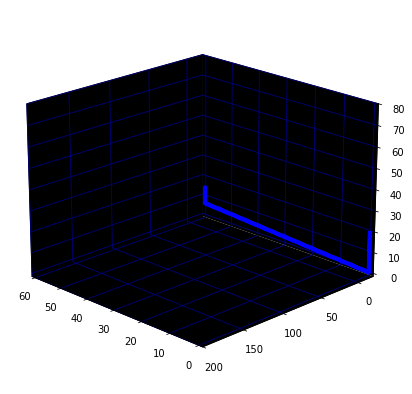

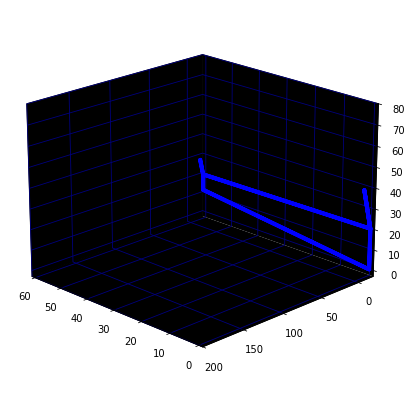

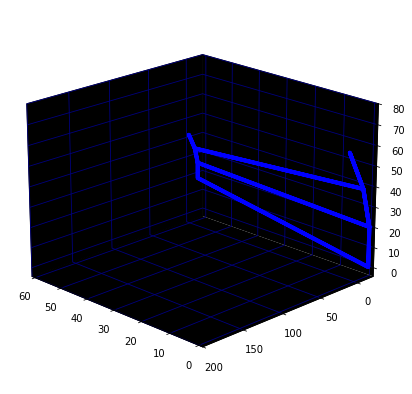

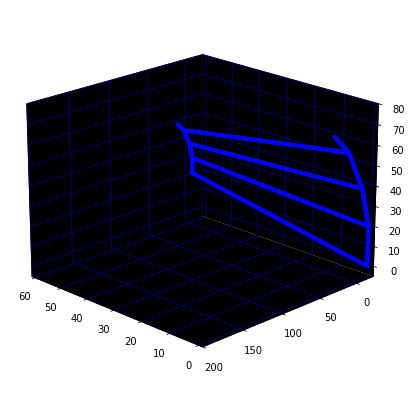

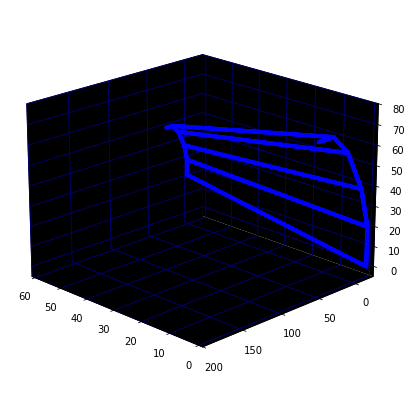

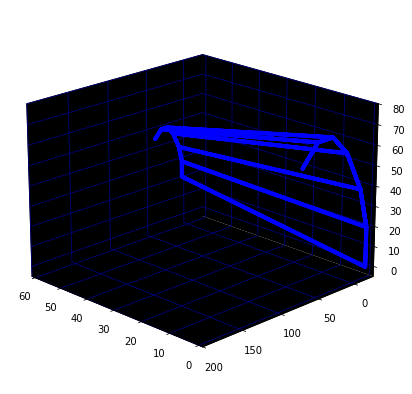

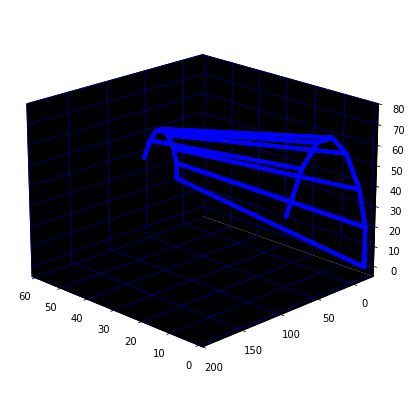

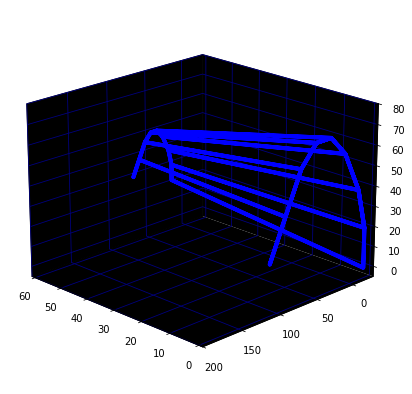

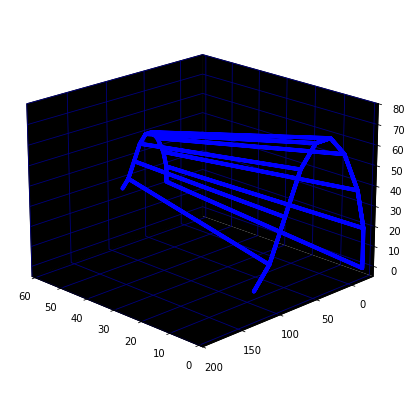

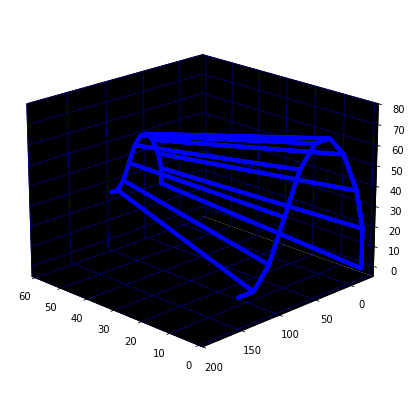

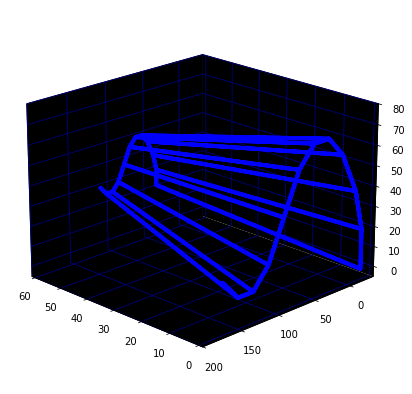

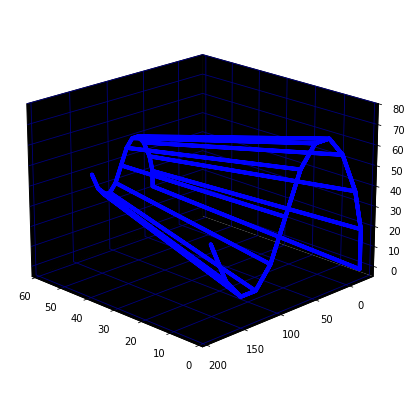

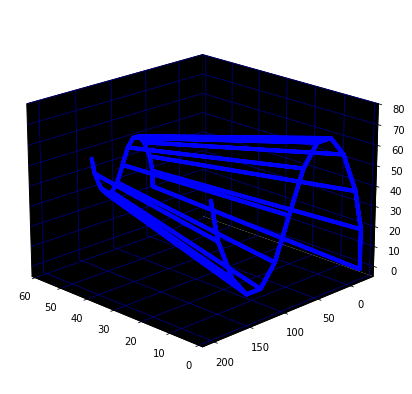

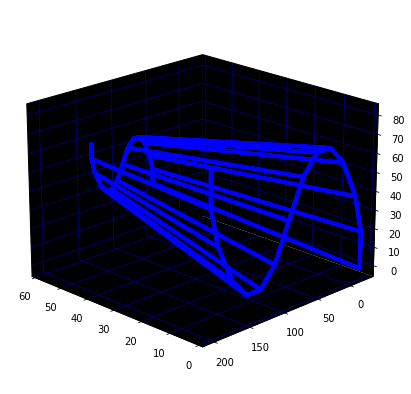

In [88]:
lines = open("webs.s",'r').readlines()

def getWebVertices(web_data):
    xs = [int(x) for x in ','.join([x for x in web_data.split() if ',' in x]).split(',')]
    l = [x*10 for x in xs]
    vertices = [(l[i],l[i+1]) for i in range(0,len(l)-1,2)]
    # if the last value is 0 we ignore the last vertex pair
    if not xs[-1]:
        vertices = vertices[:-1]
    return vertices

def writeWeb(vertices, web_name, iteration):
    x,y,z = create3DVertices(vertices[:iteration])
    makeFullGraph(x,y,z, f"gradual_web/{web_name}_{iteration}.png", "")
    return

web_name = ""
web_data = ""
all_web_data = {}
for ln in lines:
    if ":" in ln and web_name:
        all_web_data[web_name] = web_data
        web_data = ""
        web_name = ""
    if ";" in ln:
        web_name = ln.split(';')[-1].strip()
    if ":" in ln:
        continue
    web_data += ln

web_data = all_web_data["sine wave"]
vertices = getWebVertices(web_data)
for i in range(2, len(vertices)+1):
    writeWeb(vertices, "sine_wave", i)


In [89]:
vertices

[(-20, 140),
 (-20, 120),
 (-10, 100),
 (10, 80),
 (30, 70),
 (50, 70),
 (70, 80),
 (90, 100),
 (110, 120),
 (130, 130),
 (150, 130),
 (170, 120),
 (190, 100),
 (200, 80),
 (200, 60)]